# Base 3 — Gráficos exploratórios

Este notebook parte da Base 3 original, cria `datetime` e produz os gráficos exploratórios necessários para entender nível, distribuição, sazonalidade e qualidade temporal da série de `PM2.5`.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT / "src"))
from series_temporais.reporting.graficos_exploratorios import aplicar_estilo, plotar_acf

aplicar_estilo()

DATA_PATH = Path("../../bases/grupo3/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]],
    errors="coerce"
)
df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce")
df = df.sort_values("datetime").reset_index(drop=True)

target = df.dropna(subset=["PM2.5"]).copy()
target["hour"] = target["datetime"].dt.hour
target["day_of_week"] = target["datetime"].dt.dayofweek
target["month"] = target["datetime"].dt.month

print("Observações totais:", len(df))
print("Observações com PM2.5:", len(target))


Observações totais: 35064
Observações com PM2.5: 34139


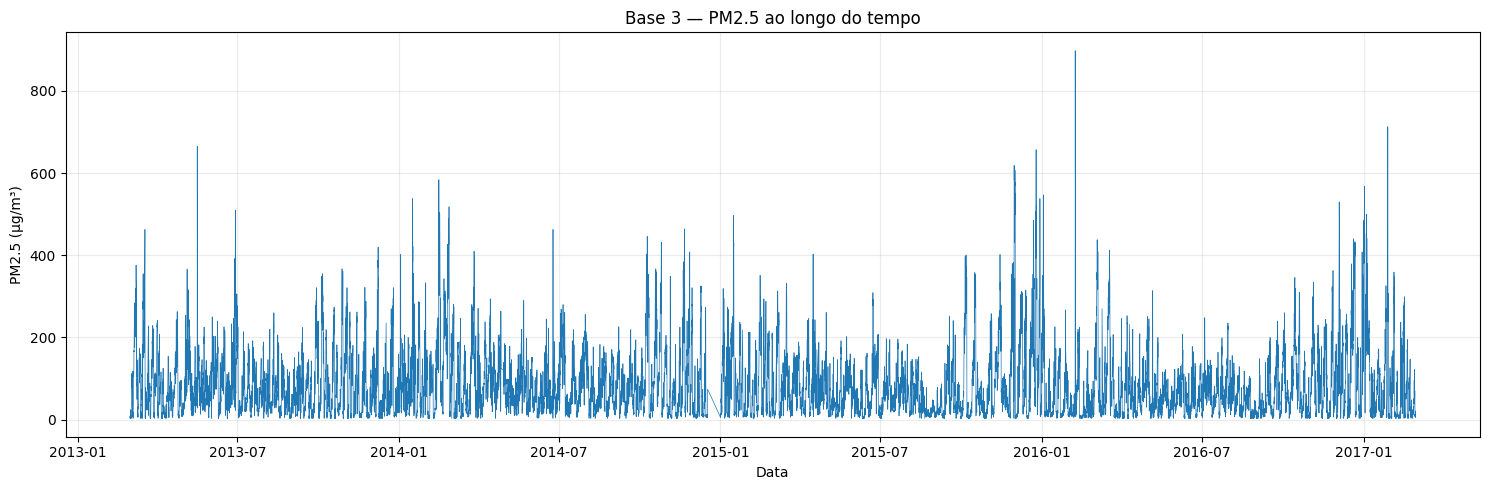

In [11]:
# 1. Série temporal completa
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(target["datetime"], target["PM2.5"], linewidth=0.5)
ax.set_title("Base 3 — PM2.5 ao longo do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


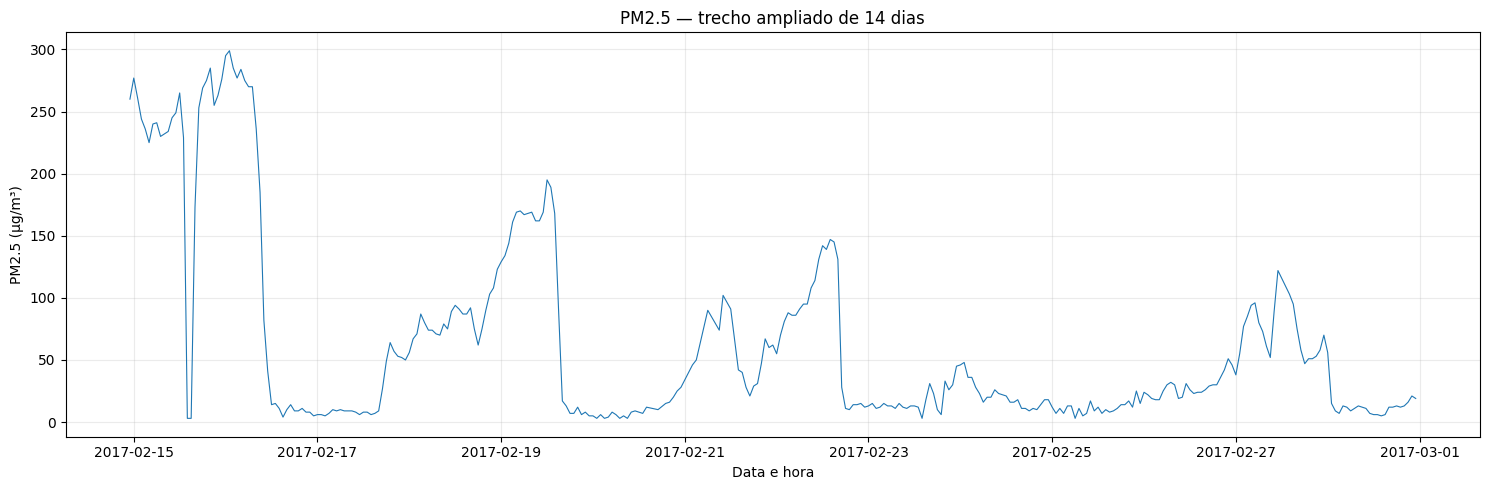

In [12]:
# 2. Trecho ampliado: últimos 14 dias disponíveis
end = target["datetime"].max()
window = target[target["datetime"] >= end - pd.Timedelta(days=14)]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(window["datetime"], window["PM2.5"], linewidth=0.8)
ax.set_title("PM2.5 — trecho ampliado de 14 dias")
ax.set_xlabel("Data e hora")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


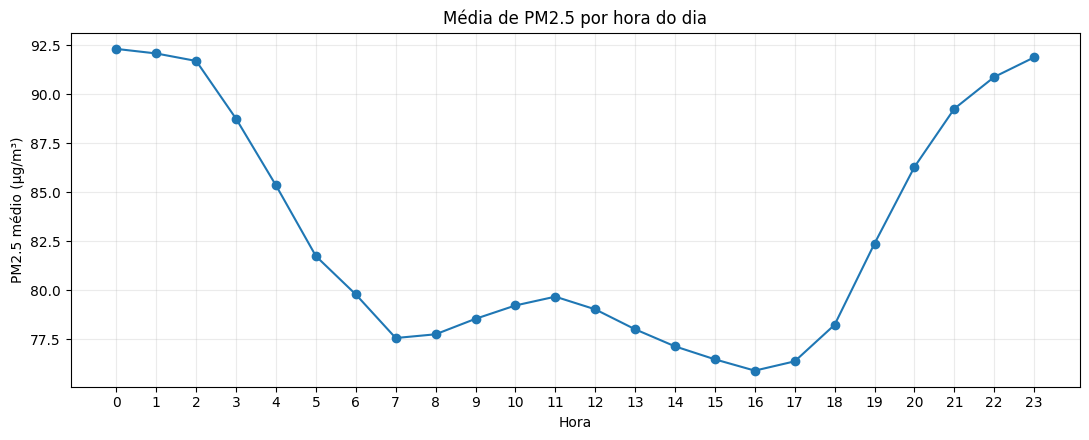

In [13]:
# 3. Média por hora do dia
hour_mean = target.groupby("hour")["PM2.5"].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hour_mean.index, hour_mean.values, marker="o", linewidth=1.5)
ax.set_title("Média de PM2.5 por hora do dia")
ax.set_xlabel("Hora")
ax.set_ylabel("PM2.5 médio (µg/m³)")
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


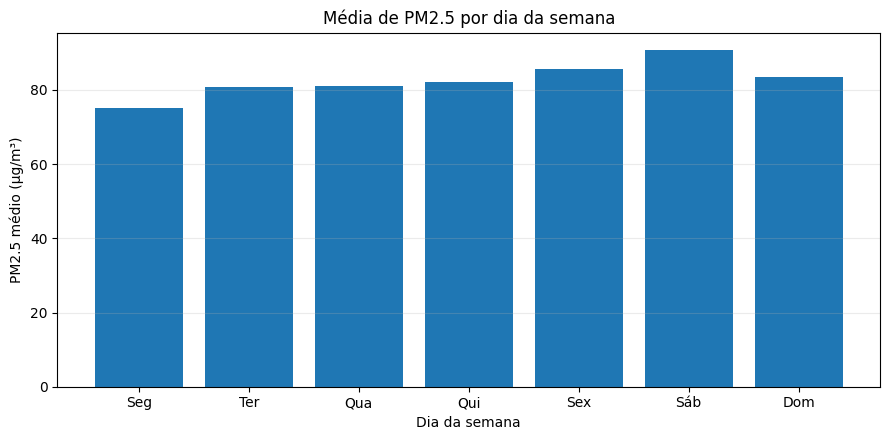

In [14]:
# 4. Média por dia da semana
dow = target.groupby("day_of_week")["PM2.5"].mean()
labels = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, dow.reindex(range(7)).values)
ax.set_title("Média de PM2.5 por dia da semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("PM2.5 médio (µg/m³)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


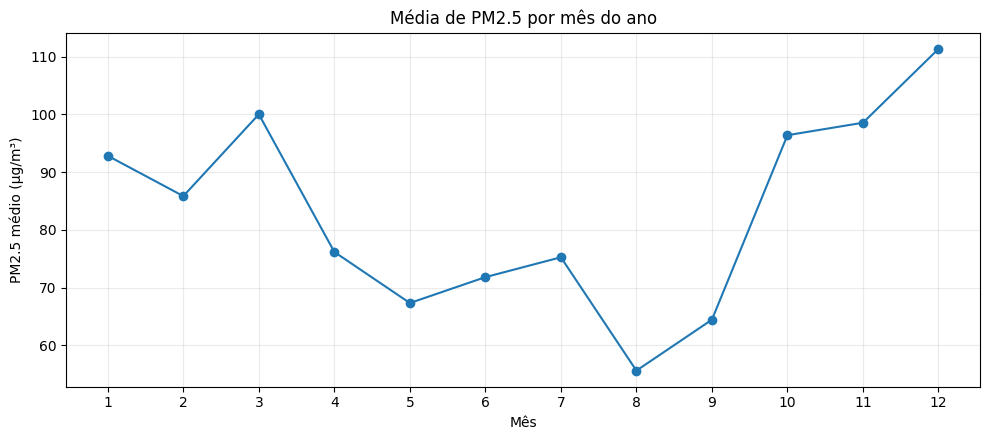

In [15]:
# 5. Média mensal ao longo do ano (mês do calendário)
month_mean = target.groupby("month")["PM2.5"].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(month_mean.index, month_mean.values, marker="o", linewidth=1.5)
ax.set_title("Média de PM2.5 por mês do ano")
ax.set_xlabel("Mês")
ax.set_ylabel("PM2.5 médio (µg/m³)")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


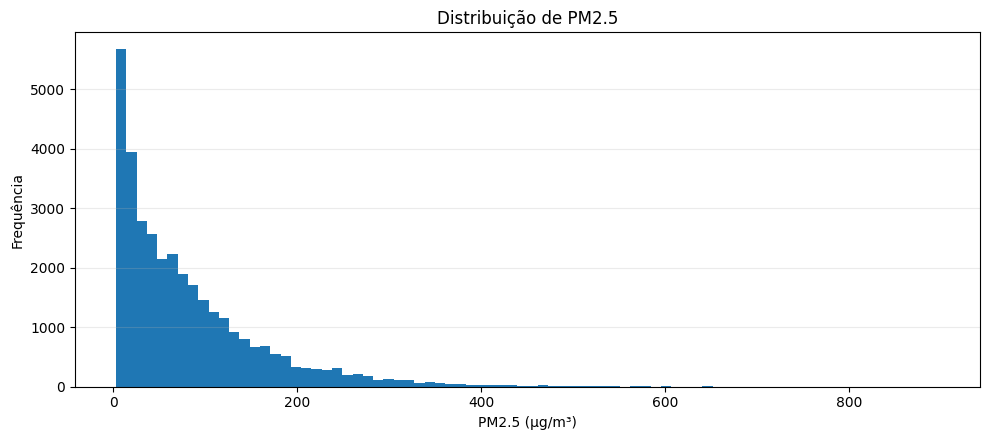

count    34139.000000
mean        82.773611
std         82.135694
min          3.000000
1%           3.000000
5%           8.000000
50%         58.000000
95%        248.000000
99%        377.000000
max        898.000000
Name: PM2.5, dtype: float64


In [16]:
# 6. Distribuição do alvo
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(target["PM2.5"], bins=80)
ax.set_title("Distribuição de PM2.5")
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Frequência")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(target["PM2.5"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


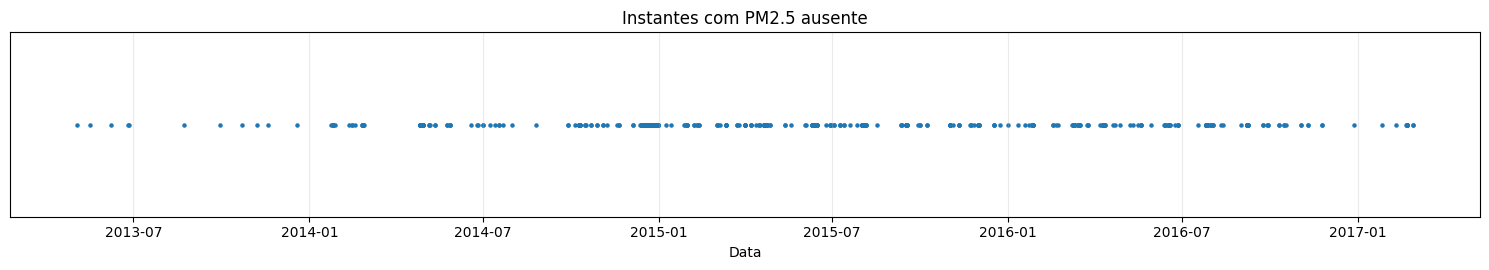

PM2.5 ausente: 925


In [17]:
# 7. Ausências ao longo do tempo
missing = df["PM2.5"].isna()

fig, ax = plt.subplots(figsize=(15, 2.8))
ax.scatter(df.loc[missing, "datetime"], np.ones(missing.sum()), s=5)
ax.set_title("Instantes com PM2.5 ausente")
ax.set_xlabel("Data")
ax.set_yticks([])
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("PM2.5 ausente:", int(missing.sum()))


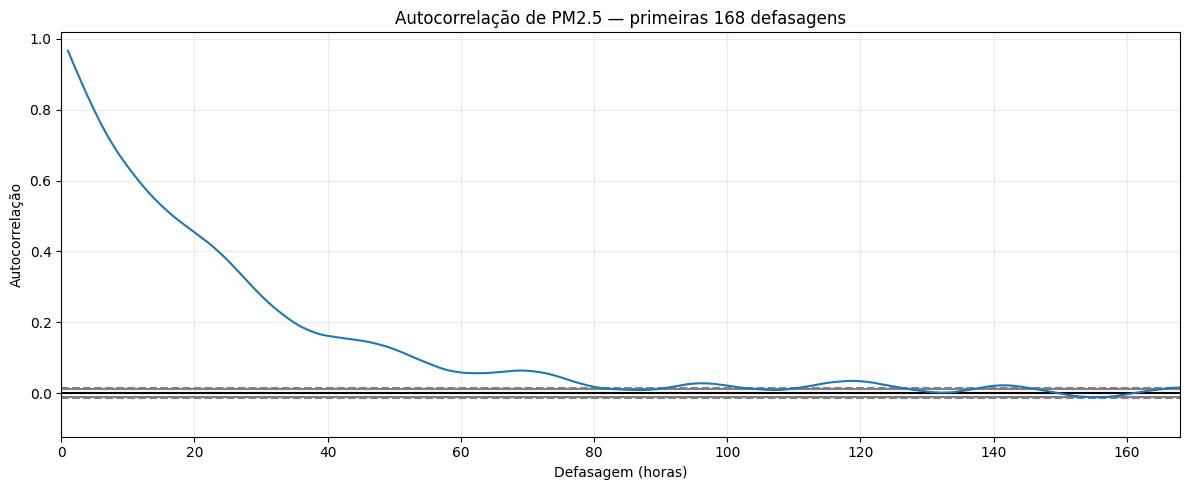

In [ ]:
# 8. ACF para as primeiras 7 dias (168 defasagens)
series = target.set_index("datetime")["PM2.5"].copy()

fig, ax = plt.subplots(figsize=(12, 5))
plotar_acf(ax, series.to_numpy(), lags=168, unidade="horas")
ax.set_title("Autocorrelação de PM2.5 — primeiras 168 defasagens")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Leitura inicial

Os gráficos devem ser usados para justificar, e não simplesmente assumir, ciclos diário e anual. A definição final dos períodos sazonais deve ser confrontada com STL e com a validação temporal do modelo.

Os picos de PM2.5 não são removidos automaticamente: valores extremos podem representar episódios reais de poluição.


### STL e sazonalidade

In [2]:
"""
STL e força da sazonalidade — Base 3 (PM2.5, Pequim) e Base 4 (Temperatura, Jena)
Pacote do P2 (Exploração + Holt-Winters, Bases 3 e 4).
 
IMPORTANTE — leia antes de colar no notebook:
Os arquivos *_treino_preparada.csv têm buracos na grade temporal, porque a
etapa de preparação faz `dropna(subset=[alvo])` DEPOIS de já ter uma grade
regular. Isso tira as linhas com o alvo ausente e quebra a frequência fixa
(819 horas faltando na janela de treino da Base 3; 99 intervalos de 10 min
faltando na Base 4). STL exige uma série com frequência fixa e sem buracos,
então este script parte dos arquivos *_limpa_preparada.csv (grade completa,
com NaN preservado), recorta a mesma janela cronológica do treino e só então
interpola os poucos pontos faltantes — apenas para esta decomposição
exploratória, não para o treino do modelo em si. Essa é uma decisão que
precisa ser documentada e validada com o grupo, não assumida em silêncio.
"""
 
from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
 
BASE_DIR = Path(".")  # ajuste para o caminho das pastas grupo3/ e grupo4/
 
 
def seasonal_strength(resid, seasonal):
    """F_S = max(0, 1 - Var(resid) / Var(seasonal + resid))  (Hyndman & Athanasopoulos)."""
    resid, seasonal = np.asarray(resid, float), np.asarray(seasonal, float)
    denom = np.nanvar(seasonal + resid)
    return np.nan if denom == 0 else max(0.0, 1 - np.nanvar(resid) / denom)
 
 
def trend_strength(resid, trend):
    resid, trend = np.asarray(resid, float), np.asarray(trend, float)
    denom = np.nanvar(trend + resid)
    return np.nan if denom == 0 else max(0.0, 1 - np.nanvar(resid) / denom)
 
 
def preparar_janela_treino(full_csv, treino_csv, col_data, col_alvo, freq):
    treino = pd.read_csv(treino_csv, parse_dates=[col_data])
    inicio, fim = treino[col_data].min(), treino[col_data].max()
 
    full = pd.read_csv(full_csv, parse_dates=[col_data]).set_index(col_data).sort_index()
    janela = full.loc[inicio:fim, col_alvo].asfreq(freq)
    n_faltando = int(janela.isna().sum())
    janela_interp = janela.interpolate(method="time", limit_direction="both")
    print(f"{col_alvo}: {len(janela)} pontos na janela de treino | "
          f"{n_faltando} pontos interpolados p/ fechar a grade")
    return janela_interp
 
 
def rodar_stl(serie, periodos: dict, robust=False):
    resultados = []
    for nome, periodo in periodos.items():
        res = STL(serie, period=periodo, robust=robust).fit()
        resultados.append({
            "periodo": nome,
            "n_obs_por_ciclo": periodo,
            "forca_sazonalidade": round(seasonal_strength(res.resid, res.seasonal), 4),
            "forca_tendencia": round(trend_strength(res.resid, res.trend), 4),
        })
    return pd.DataFrame(resultados)



if __name__ == "__main__":
    # ---------------- Base 3 — PM2.5, grade horária ----------------
    pm25 = preparar_janela_treino(
        BASE_DIR / "base3_limpa_preparada.csv",
        BASE_DIR / "base3_treino_preparada.csv",
        "datetime", "PM2.5", "h",
    )
    tab_b3 = rodar_stl(pm25, {"diaria (24h)": 24, "semanal (168h)": 168})
    # sazonalidade anual (period=8760) é pesada (~3 min); rode à parte se precisar
    print("\nBase 3 — força da sazonalidade (PM2.5):")
    print(tab_b3.to_string(index=False))

PM2.5: 28130 pontos na janela de treino | 819 pontos interpolados p/ fechar a grade

Base 3 — força da sazonalidade (PM2.5):
       periodo  n_obs_por_ciclo  forca_sazonalidade  forca_tendencia
  diaria (24h)               24              0.3970           0.8739
semanal (168h)              168              0.3314           0.3801
